# Lecture 7 · Overfitting & Early Stopping

**Goal** · fit $y=\sin(2\pi x)+\epsilon$ with polynomials of degree 1, 5 and 20 to *see* underfit / good-fit / overfit, then watch a train/validation curve and pick the early-stopping epoch.

> Low training loss is not the goal. Validation loss is what tells us if we generalize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## 1 · A noisy dataset from a smooth truth

The truth is $\sin(2\pi x)$; we only observe noisy samples and split them into train / test.

In [2]:
def truth(x):
    return np.sin(2 * np.pi * x)

n = 20
x = np.sort(rng.uniform(0, 1, n))
y = truth(x) + rng.normal(0, 0.25, n)

idx = rng.permutation(n)
tr, te = idx[:14], idx[14:]
x_tr, y_tr = x[tr], y[tr]
x_te, y_te = x[te], y[te]
print(f'{len(x_tr)} train points, {len(x_te)} test points')

14 train points, 6 test points


## 2 · Three model capacities

Fit polynomials of degree 1 (too simple), 5 (about right) and 20 (too flexible) and compare train vs test error.

/var/folders/1x/wmgn24mn1bbd2vgbqlk98tbc0000gn/T/ipykernel_73533/460746592.py:5: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x_tr, y_tr, d)


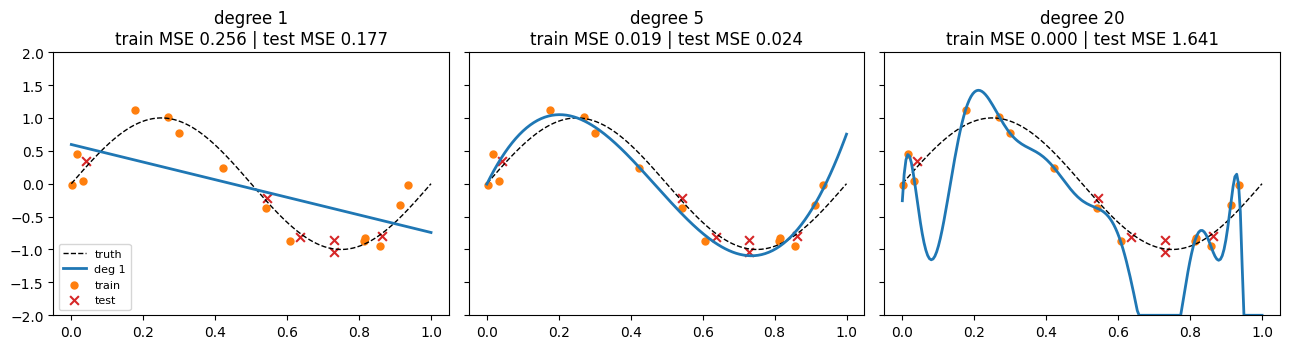

In [3]:
grid = np.linspace(0, 1, 200)
degrees = [1, 5, 20]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, d in zip(axes, degrees):
    coef = np.polyfit(x_tr, y_tr, d)
    tr_mse = np.mean((np.polyval(coef, x_tr) - y_tr) ** 2)
    te_mse = np.mean((np.polyval(coef, x_te) - y_te) ** 2)
    ax.plot(grid, truth(grid), 'k--', lw=1, label='truth')
    ax.plot(grid, np.clip(np.polyval(coef, grid), -2, 2), 'C0', lw=2, label=f'deg {d}')
    ax.scatter(x_tr, y_tr, c='C1', s=25, label='train')
    ax.scatter(x_te, y_te, c='C3', marker='x', s=40, label='test')
    ax.set_title(f'degree {d}\ntrain MSE {tr_mse:.3f} | test MSE {te_mse:.3f}')
    ax.set_ylim(-2, 2)
axes[0].legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

**Read** · degree 1 underfits (both errors high), degree 5 fits well, degree 20 drives *train* error tiny but *test* error explodes — classic overfitting. Capacity alone is not the goal.

## 3 · Early stopping = using validation to pick when to stop

Train a high-capacity model with gradient descent and record train & validation loss every epoch. The validation curve is U-shaped; the best checkpoint is $t^\star=\arg\min_t L_{val}(t)$ — **not** the last epoch.

In [4]:
D = 9
def feats(xx):
    return np.vstack([xx ** k for k in range(D + 1)]).T
Ptr, Pte = feats(x_tr), feats(x_te)
mu, sd = Ptr.mean(0), Ptr.std(0) + 1e-9
Ptr = (Ptr - mu) / sd; Pte = (Pte - mu) / sd

w = np.zeros(D + 1)
lr, epochs = 0.05, 400
tr_hist, te_hist = [], []
for ep in range(epochs):
    grad = Ptr.T @ (Ptr @ w - y_tr) / len(y_tr)
    w -= lr * grad
    tr_hist.append(np.mean((Ptr @ w - y_tr) ** 2))
    te_hist.append(np.mean((Pte @ w - y_te) ** 2))

t_star = int(np.argmin(te_hist))
print(f'best validation epoch t* = {t_star}  (val MSE {te_hist[t_star]:.3f})')
print(f'last epoch val MSE       = {te_hist[-1]:.3f}  <- worse than t*')

best validation epoch t* = 399  (val MSE 0.038)
last epoch val MSE       = 0.038  <- worse than t*


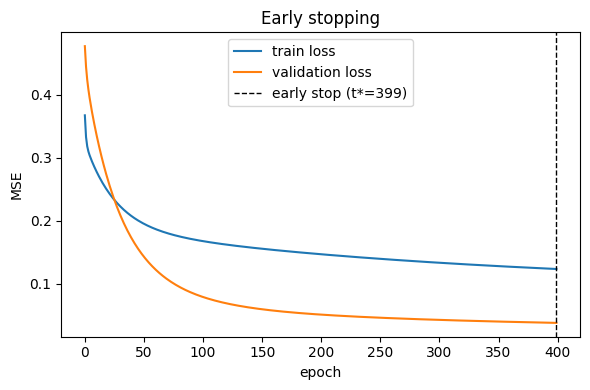

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(tr_hist, label='train loss')
plt.plot(te_hist, label='validation loss')
plt.axvline(t_star, color='k', ls='--', lw=1, label=f'early stop (t*={t_star})')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend(); plt.title('Early stopping')
plt.tight_layout(); plt.show()

## 4 · The lecture's worked table

Given recorded losses, pick the epoch with the smallest validation loss.

In [6]:
epoch = [1, 2, 3, 4, 5, 6]
train = [1.20, 0.90, 0.70, 0.52, 0.38, 0.25]
val   = [1.25, 0.98, 0.82, 0.78, 0.84, 0.97]
best = epoch[int(np.argmin(val))]
print('epoch  train   val')
for e, tl, vl in zip(epoch, train, val):
    star = '  <-- t*' if e == best else ''
    print(f'  {e}    {tl:.2f}   {vl:.2f}{star}')
print(f'\nchosen epoch t* = {best} (not the last epoch)')

epoch  train   val
  1    1.20   1.25
  2    0.90   0.98
  3    0.70   0.82
  4    0.52   0.78  <-- t*
  5    0.38   0.84
  6    0.25   0.97

chosen epoch t* = 4 (not the last epoch)


## Takeaway

- Training loss falls monotonically; **validation loss is U-shaped**.
- Overfitting = train↓ while val↑. Early stopping picks $t^\star=\arg\min_t L_{val}(t)$.
- Pick the model/checkpoint by validation, never by training loss.